In [107]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import gc
import os
import glob
import random
import re
import shutil
import evaluate
from tqdm import tqdm
from pathlib import Path
from torch.utils.data import Sampler, Dataset as TorchDataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from google.colab import drive
from torch import Tensor
from einops import rearrange, reduce
from einops.layers.torch import Rearrange, Reduce
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    AutoConfig,
    EarlyStoppingCallback
)
from datasets import Dataset, concatenate_datasets

In [1]:
pip install evaluate jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 65.2 MB/s eta 0:00:00


# cnn+transformer

## CNN

In [3]:
class PatchEmbedding(nn.Module):
    def __init__(self, emb_size=256, num_electrodes=512,
                 temporal_kernel=(1, 10), pool_kernel=(1, 15), pool_stride=(1, 8)):
        super().__init__()

        # same-padding
        pad_w = temporal_kernel[1] // 2

        # Temporal Conv (same padding), conv over time dimension (1,5) = receptive field of 5 bins x 20 ms = 100 ms
        self.temporal_conv = nn.Conv2d(
            in_channels=1, out_channels=256,
            kernel_size=temporal_kernel, stride=(1, 1), padding=(0, pad_w)
        )

        # Spatial dimension is collapsed from 512 -> 1
        self.spatial_conv = nn.Conv2d(256, 256, kernel_size=(num_electrodes, 1),
                                      stride=(1, 1), groups=256)

        # Batch Normalisation + Activation
        self.bn  = nn.BatchNorm2d(256)
        self.act = nn.ELU()

        # Average Pooling  (temporal downsampling)
        self.pool = nn.AvgPool2d(kernel_size=pool_kernel, stride=pool_stride)
        self.dropout = nn.Dropout(0.5)

        # Projection feature channels (256) to target embedding dimension for transformer encoder
        # Shape  (Batch, emb_size, Height (1), num_tokens) -> (Batch, num_tokens, emb_size)
        self.projection = nn.Sequential(
            nn.Conv2d(256, emb_size, kernel_size=(1, 1), stride=(1, 1)),
            Rearrange('b e (h) (w) -> b (h w) e'),
        )

    def forward(self, x: Tensor) -> Tensor:
        x = self.temporal_conv(x)
        x = self.spatial_conv(x)
        x = self.bn(x)
        x = self.act(x)
        x = self.pool(x)
        x = self.dropout(x)
        x = self.projection(x)
        return x

## Transformer

In [4]:
class PositionalEncoding(nn.Module):
    def __init__(self, emb_size: int, dropout: float = 0.1, max_len: int = 5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Create a matrix of shape (max_len, emb_size)
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, emb_size, 2) * (-math.log(10000.0) / emb_size))

        pe = torch.zeros(1, max_len, emb_size)
        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)

        # register_buffer ensures it's saved with the model but not updated by the optimizer
        self.register_buffer('pe', pe)

    def forward(self, x: Tensor) -> Tensor:
        # x: Tensor, shape (Batch, num_tokens, emb_size)
        # Add the positional encoding up to the current sequence length
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

In [5]:
class MultiHeadAttention(nn.Module):
    def __init__(self, emb_size: int, num_heads: int, dropout: float):
        super().__init__()
        assert emb_size % num_heads == 0, f"emb_size ({emb_size}) must be divisible by num_heads ({num_heads})"

        self.emb_size  = emb_size
        self.num_heads = num_heads
        self.head_dim  = emb_size // num_heads
        self.dropout_p = dropout

        self.queries    = nn.Linear(emb_size, emb_size)
        self.keys       = nn.Linear(emb_size, emb_size)
        self.values     = nn.Linear(emb_size, emb_size)
        self.projection = nn.Linear(emb_size, emb_size)

    def forward(self, x: Tensor, mask: Tensor = None) -> Tensor:
        Q = rearrange(self.queries(x), "b n (h d) -> b h n d", h=self.num_heads)
        K = rearrange(self.keys(x),    "b n (h d) -> b h n d", h=self.num_heads)
        V = rearrange(self.values(x),  "b n (h d) -> b h n d", h=self.num_heads)

        # FlashAttention
        out = F.scaled_dot_product_attention(
            Q, K, V,
            attn_mask=mask,
            dropout_p=self.dropout_p if self.training else 0.0,
            is_causal=False
        )

        out = rearrange(out, "b h n d -> b n (h d)")
        out = self.projection(out)
        return out

### 残差连接器

In [6]:
class ResidualAdd(nn.Module):
    def __init__(self, fn: nn.Module):
        """
        Args:
            fn : Any sub-module whose input and output shapes match.
        """
        super().__init__()
        self.fn = fn

    def forward(self, x: Tensor, **kwargs) -> Tensor:
        residual = x
        x = self.fn(x, **kwargs)
        return x + residual


In [7]:
class FeedForwardBlock(nn.Sequential):
    def __init__(self, emb_size: int, expansion: int = 4, drop_p: float = 0.5):
        """
        Args:
            emb_size  : Input and output feature dimension.
            expansion : Hidden layer size multiplier (hidden = expansion x emb_size).
            drop_p    : Dropout probability applied after the first linear layer.
        """
        super().__init__(
            nn.Linear(emb_size, expansion * emb_size),  # expand
            nn.GELU(),                                    # smooth activation
            nn.Dropout(drop_p),
            nn.Linear(expansion * emb_size, emb_size),  # project back
        )


### 单个transformer模块

In [8]:
class TransformerEncoderBlock(nn.Module):
    def __init__(
        self,
        emb_size: int,
        num_heads: int = 8,
        drop_p: float = 0.3,
        forward_expansion: int = 4,
        forward_drop_p: float = 0.3
    ):
        super().__init__()
        # Sub-layer 1: self-attention
        self.norm1 = nn.LayerNorm(emb_size)
        self.attn = MultiHeadAttention(emb_size, num_heads, drop_p)
        self.drop1 = nn.Dropout(drop_p)

        # Sub-layer 2: feed-forward
        self.norm2 = nn.LayerNorm(emb_size)
        self.ff = FeedForwardBlock(emb_size, expansion=forward_expansion, drop_p=forward_drop_p)
        self.drop2 = nn.Dropout(drop_p)

    def forward(self, x: Tensor, mask: Tensor = None) -> Tensor:
        # Self-attention with residual connection
        res = x
        x = self.norm1(x)
        x = self.attn(x, mask=mask)  # Pass the mask here!
        x = res + self.drop1(x)

        # Feed-forward with residual connection
        res = x
        x = self.norm2(x)
        x = self.ff(x)
        x = res + self.drop2(x)
        return x

### 多层transformer堆叠

In [9]:
class TransformerEncoder(nn.Module):
    def __init__(self, depth: int, emb_size: int):
        super().__init__()
        # Use nn.ModuleList instead of nn.Sequential
        self.layers = nn.ModuleList([
            TransformerEncoderBlock(emb_size) for _ in range(depth)
        ])

    def forward(self, x: Tensor, mask: Tensor = None) -> Tensor:
        # Loop through each layer and pass the mask down
        for layer in self.layers:
            x = layer(x, mask=mask)
        return x


## 神经网络总体堆叠

In [10]:
class NeuralEncoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.patch_embedding = PatchEmbedding(
            emb_size=config['emb_size'],
            num_electrodes=config['num_electrodes'],
            temporal_kernel=config['temporal_kernel'],
            pool_kernel=config['pool_kernel'],
            pool_stride=config['pool_stride']
        )
        self.pos_encoder = PositionalEncoding(
            emb_size=config['emb_size'],
            dropout=config['drop_p']
        )
        self.transformer = TransformerEncoder(depth=config['depth'], emb_size=config['emb_size'])
        self.norm = nn.LayerNorm(config['emb_size'])

    def forward(self, x: Tensor, input_lengths: Tensor = None) -> Tensor:
        x = self.patch_embedding(x)
        x = self.pos_encoder(x)

        # --- ATTENTION MASK CREATION ---
        mask = None
        if input_lengths is not None:
            B, T, _ = x.shape
            seq_range = torch.arange(T, device=x.device).expand(B, T)
            bool_mask = seq_range < input_lengths.unsqueeze(1)
            mask = bool_mask.unsqueeze(1).unsqueeze(2)
        # -------------------------------

        x = self.transformer(x, mask=mask)
        x = self.norm(x)
        return x


In [11]:
class PhonemeHead(nn.Module):
    """
    FFN head for per-timestep phoneme prediction.
    Plugged in after NeuralEncoder output.

    Input : (B, num_tokens, emb_size)
    Output: (B, num_tokens, num_phonemes + 1)
              +1 = CTC blank token (index 0)
    """
    def __init__(
        self,
        emb_size    : int,
        num_phonemes: int,   # Don't have blank，40 for the English language
        ffn_hidden  : int   = 256,
        drop_p      : float = 0.3,
    ):
        super().__init__()

        self.ffn = nn.Sequential(
            nn.Linear(emb_size, ffn_hidden),
            nn.GELU(),
            nn.Dropout(drop_p),
            nn.Linear(ffn_hidden, num_phonemes + 1),  # +1 for blank
        )

    def forward(self, x: Tensor) -> Tensor:
        """
        Args:
            x : (B, num_tokens, emb_size)
        Returns:
            (B, num_tokens, num_phonemes + 1)
        """
        return self.ffn(x)

In [12]:
# ===============================================================
# Configurable Model Components
# ===============================================================
class NeuralSpeechModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.encoder = NeuralEncoder(config)
        self.head = PhonemeHead(
            emb_size=config['emb_size'],
            num_phonemes=config['num_phonemes'],
            ffn_hidden=config['ffn_hidden'],
            drop_p=config['drop_p'],
        )

    def forward(self, x: Tensor, input_lengths: Tensor = None):
        x = self.encoder(x, input_lengths) # Pass lengths to encoder
        x = self.head(x)
        x = F.log_softmax(x, dim=-1)
        num_tokens = x.shape[1]
        x = x.permute(1, 0, 2)
        return x, num_tokens

In [13]:
# ===============================================================
# Configurable Training & Validation
# ===============================================================

def compute_token_lengths(input_time_steps: torch.Tensor, pool_kernel: int, pool_stride: int):
    # Length after pooling: floor((T - kernel) / stride) + 1
    return ((input_time_steps - pool_kernel) // pool_stride + 1).long()

def train_one_epoch(model, optimizer, train_loader, device, scaler):
    model.train()
    total_loss = 0
    num_batches = 0

    # Extract kernel/stride from model config for accurate CTC length math
    k_w = model.config['pool_kernel'][1]
    s_w = model.config['pool_stride'][1]

    for neural_batch, phoneme_batch, seq_len_batch, input_time_steps in train_loader:
      # Safty net
      try:
          neural_batch  = neural_batch.to(device)
          phoneme_batch = phoneme_batch.to(device)
          seq_len_batch = seq_len_batch.to(device)

          input_lengths = compute_token_lengths(
              input_time_steps, pool_kernel=k_w, pool_stride=s_w
          ).to(device)

          optimizer.zero_grad()

          # Automatic Mixed Precision (AMP) Step 1: Wrap forward pass and loss in autocast - FP16
          with torch.autocast(device_type=device.type, dtype=torch.float16):
              log_probs, num_tokens = model(neural_batch, input_lengths)

          loss = F.ctc_loss(
              log_probs, phoneme_batch, input_lengths, seq_len_batch,
              blank=0, reduction='mean', zero_infinity=True
          )

          # AMP Step 2: Scale the loss and backpropagate
          scaler.scale(loss).backward()

          # AMP Step 3: Unscale gradients BEFORE clipping
          scaler.unscale_(optimizer)
          torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

          # AMP Step 4: Optimizer step and Scaler update
          scaler.step(optimizer)
          scaler.update()

          total_loss += loss.item()
          num_batches += 1

      except torch.cuda.OutOfMemoryError:
          print(f"\n Skipping a killer batch due to OOM spike...")
          torch.cuda.empty_cache()
          optimizer.zero_grad()
          continue

    return (total_loss / num_batches) if num_batches > 0 else float('inf')

def validate(model, val_loader, device):
    model.eval()
    total_loss = 0
    num_batches = 0

    k_w = model.config['pool_kernel'][1]
    s_w = model.config['pool_stride'][1]

    with torch.no_grad():
        for neural_batch, phoneme_batch, seq_len_batch, input_time_steps in val_loader:
            neural_batch  = neural_batch.to(device)
            phoneme_batch = phoneme_batch.to(device)
            seq_len_batch = seq_len_batch.to(device)

            input_lengths = compute_token_lengths(
                input_time_steps, pool_kernel=k_w, pool_stride=s_w
            ).to(device)

            with torch.autocast(device_type=device.type, dtype=torch.float16):
                log_probs, num_tokens = model(neural_batch, input_lengths)

            loss = F.ctc_loss(
                log_probs, phoneme_batch, input_lengths, seq_len_batch,
                blank=0, reduction='mean', zero_infinity=True
            )
            total_loss += loss.item()
            num_batches += 1

    return total_loss / num_batches

In [14]:
def preprocess_neural_data(neural_data: np.ndarray) -> np.ndarray:
    # Z-score normalisation using training-set statistics.
    # Mean and std are computed per feature across all trials and time steps,
    # giving a (1, 1, 512) statistics vector.
    mean = neural_data.mean(axis=(0, 1), keepdims=True)
    std  = neural_data.std(axis=(0, 1),  keepdims=True) + 1e-8   # epsilon avoids /0
    neural_data = (neural_data - mean) / std

    # Reshape: (N, T, 512) -> (N, 512, T) -> (N, 1, 512, T)
    neural_data = neural_data.transpose(0, 2, 1)    # swap time and feature axes
    neural_data = np.expand_dims(neural_data, 1)    # add channel dimension for Conv2d
    return neural_data


# 数据代入实验

In [15]:
drive.mount('/content/drive')

Mounted at /content/drive


In [22]:
# ===============================================================
# Load single hdf5 file
# ===============================================================

def load_h5py_file(file_path):
    data = {
        'neural_features': [], 'n_time_steps': [], 'seq_class_ids': [],
        'seq_len': [], 'transcriptions': [], 'sentence_label': [],
        'session': [], 'block_num': [], 'trial_num': [],
    }
    with h5py.File(file_path, 'r') as f:
        keys = list(f.keys())
        for key in keys:
            g = f[key]

            # Extract arrays and attributes
            neural_features = g['input_features'][:]
            n_time_steps = g.attrs['n_time_steps']
            seq_class_ids = g['seq_class_ids'][:] if 'seq_class_ids' in g else None
            seq_len = g.attrs['seq_len'] if 'seq_len' in g.attrs else None
            transcription = g['transcription'][:] if 'transcription' in g else None
            sentence_label = g.attrs['sentence_label'][:] if 'sentence_label' in g.attrs else None
            session = g.attrs['session']
            block_num = g.attrs['block_num']
            trial_num = g.attrs['trial_num']

            # Append to lists
            data['neural_features'].append(neural_features)
            data['n_time_steps'].append(n_time_steps)
            data['seq_class_ids'].append(seq_class_ids)
            data['seq_len'].append(seq_len)
            data['transcriptions'].append(transcription)
            data['sentence_label'].append(sentence_label)
            data['session'].append(session)
            data['block_num'].append(block_num)
            data['trial_num'].append(trial_num)
    return data

# ================================================================
# Load multiple hdf5 files
# ================================================================

def load_all_files(drive_dir: str, local_dir: str, split: str, max_files: int = None):
    """
    Searches through all session folders in drive_dir, copies them to local_dir,
    and merges all files matching data_{split}.hdf5 directly into one dictionary.
    If the files already exist locally, it skips the Drive search and loads them directly.

    Args:
        drive_dir (str): The root directory on Drive to search in.
        local_dir (str): The local directory to copy the files to.
        split (str): The data split string (e.g., 'train', 'test').
        max_files (int, optional): The maximum number of files to load.
                                   If None, loads all available files.
    """
    # 1. Check local directory first to see if we can skip the Drive entirely
    local_search_pattern = os.path.join(local_dir, '**', f'data_{split}.hdf5')
    local_file_paths = sorted(glob.glob(local_search_pattern, recursive=True))

    skip_drive_search = False

    # If we have files locally, check if we have enough to skip querying Drive
    if local_file_paths:
        if max_files is None:
            skip_drive_search = True  # Assume all files were previously copied
        elif len(local_file_paths) >= max_files:
            skip_drive_search = True
            local_file_paths = local_file_paths[:max_files] # Trim to max_files

    if skip_drive_search:
        print(f"Found {len(local_file_paths)} existing session files locally for '{split}'. Skipping Drive search...")
    else:
        # 2. Search and copy from Drive if local files are missing or insufficient
        search_pattern = os.path.join(drive_dir, '**', f'data_{split}.hdf5')
        drive_file_paths = sorted(glob.glob(search_pattern, recursive=True))

        if not drive_file_paths:
            raise FileNotFoundError(f"Could not find any 'data_{split}.hdf5' files in {drive_dir}")

        # Limit the number of files if max_files is provided
        if max_files is not None:
            drive_file_paths = drive_file_paths[:max_files]

        print(f"Found {len(drive_file_paths)} session files for '{split}'. Copying to local disk...")
        local_file_paths = []

        for drive_path in drive_file_paths:
            rel_path = os.path.relpath(drive_path, drive_dir)
            local_path = os.path.join(local_dir, rel_path)
            os.makedirs(os.path.dirname(local_path), exist_ok=True)

            # Copy the file only if it hasn't been copied already
            if not os.path.exists(local_path):
                shutil.copy2(drive_path, local_path)

            local_file_paths.append(local_path)

        print("Copying complete.")

    print("Loading and merging data...")

    # 3. Initialize the master dictionary
    merged_data = {
        'neural_features': [], 'n_time_steps': [], 'seq_class_ids': [],
        'seq_len': [], 'transcriptions': [], 'sentence_label': [],
        'session': [], 'block_num': [], 'trial_num': [],
    }

    # 4. Read from the LOCAL files
    for path in local_file_paths:
        with h5py.File(path, 'r') as f:
            for key in f.keys():
                g = f[key]

                # Extract and append directly to the master lists
                merged_data['neural_features'].append(g['input_features'][:])
                merged_data['n_time_steps'].append(g.attrs['n_time_steps'])

                # Arrays with fallback for missing data
                merged_data['seq_class_ids'].append(g['seq_class_ids'][:] if 'seq_class_ids' in g else None)
                merged_data['transcriptions'].append(g['transcription'][:] if 'transcription' in g else None)

                # Using .get() for attributes is faster and cleaner than checking with 'in'
                merged_data['seq_len'].append(g.attrs.get('seq_len'))
                merged_data['sentence_label'].append(g.attrs.get('sentence_label'))

                merged_data['session'].append(g.attrs['session'])
                merged_data['block_num'].append(g.attrs['block_num'])
                merged_data['trial_num'].append(g.attrs['trial_num'])

    print(f"Successfully merged {len(merged_data['neural_features'])} total '{split}' trials.\n")
    return merged_data

# ================================================================
# Load to dataset
# ================================================================

class SpeechDataset(TorchDataset):
    def __init__(self, data_dict, max_time_steps):
        self.data = data_dict
        self.length = len(data_dict['neural_features'])
        self.max_time_steps = max_time_steps

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        # 1. Retrieve true lengths
        n_time_steps = int(self.data['n_time_steps'][idx])
        seq_len = int(self.data['seq_len'][idx])

        # 2. Slice off the padding saved in the HDF5 file using true lengths
        effective_n_steps = min(n_time_steps, self.max_time_steps)
        neural = self.data['neural_features'][idx][:effective_n_steps]
        phonemes = self.data['seq_class_ids'][idx][:seq_len]

        # 3. Reshape neural data: (T, 512) -> (512, T) -> (1, 512, T)
        neural_tensor = torch.from_numpy(neural).float()       # (T, 512)
        neural_tensor = neural_tensor.transpose(0, 1)          # (512, T)
        neural_tensor = neural_tensor.unsqueeze(0)             # (1, 512, T)

        phoneme_tensor = torch.from_numpy(phonemes.astype(np.int64))

        return neural_tensor, phoneme_tensor, seq_len, effective_n_steps

# ================================================================
# collate_fn
# ================================================================

def collate_fn(batch):
    neurals, phonemes_list, seq_lens, time_steps = zip(*batch)

    # Unpack (1, 512, T) -> (T, 512) for C++ optimized padding
    neurals_reshaped = [n.squeeze(0).transpose(0, 1) for n in neurals]

    # pad_sequence handles the memory allocation and padding in the backend
    neural_batch = pad_sequence(neurals_reshaped, batch_first=True) # -> (B, max_T, 512)

    # Repack to (B, 1, 512, max_T) for the CNN
    neural_batch = neural_batch.transpose(1, 2).unsqueeze(1)

    phoneme_batch = pad_sequence(phonemes_list, batch_first=True, padding_value=0)
    seq_len_batch = torch.tensor(seq_lens, dtype=torch.long)
    time_step_batch = torch.tensor(time_steps, dtype=torch.long)

    return neural_batch, phoneme_batch, seq_len_batch, time_step_batch


class SpeechDatasetWithText(TorchDataset):
    def __init__(self, data_dict, max_time_steps):
        self.data = data_dict
        self.length = len(data_dict['neural_features'])
        self.max_time_steps = max_time_steps

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        n_time_steps = int(self.data['n_time_steps'][idx])
        seq_len = int(self.data['seq_len'][idx])
        effective_n_steps = min(n_time_steps, self.max_time_steps)

        neural = self.data['neural_features'][idx][:effective_n_steps]
        phonemes = self.data['seq_class_ids'][idx][:seq_len]

        # Extract and decode the text label
        text_label = self.data['sentence_label'][idx]
        if isinstance(text_label, bytes):
            text_label = text_label.decode('utf-8')

        neural_tensor = torch.from_numpy(neural).float().transpose(0, 1).unsqueeze(0)
        phoneme_tensor = torch.from_numpy(phonemes.astype(np.int64))

        return neural_tensor, phoneme_tensor, seq_len, effective_n_steps, text_label


def collate_fn_with_text(batch):
    neurals, phonemes_list, seq_lens, time_steps, texts = zip(*batch)

    # Reshape for padding (T, 512)
    neurals_reshaped = [n.squeeze(0).transpose(0, 1) for n in neurals]

    # Pad neural sequences and reshape back to (B, 1, 512, max_T)
    neural_batch = pad_sequence(neurals_reshaped, batch_first=True).transpose(1, 2).unsqueeze(1)

    # Pad phonemes
    phoneme_batch = pad_sequence(phonemes_list, batch_first=True, padding_value=0)

    return neural_batch, phoneme_batch, torch.tensor(seq_lens), torch.tensor(time_steps), texts

In [17]:
# Sort dataset by n_time_steps before feed to DataLoader

class BucketBatchSampler(Sampler):
    def __init__(self, dataset, batch_size, drop_last=False):
        self.dataset = dataset
        self.batch_size = batch_size
        self.drop_last = drop_last

        # Sort all data indices by the actual time steps of the trial
        self.sorted_indices = sorted(
            range(len(dataset)),
            key=lambda i: dataset.data['n_time_steps'][i]
        )

    def __iter__(self):
        # Group the sorted indices into batches
        batches = [self.sorted_indices[i:i + self.batch_size]
                   for i in range(0, len(self.sorted_indices), self.batch_size)]

        # Shuffle the order of the batches so the model doesn't just learn "short to long"
        random.shuffle(batches)

        for batch in batches:
            if not self.drop_last or len(batch) == self.batch_size:
                yield batch

    def __len__(self):
        if self.drop_last:
            return len(self.dataset) // self.batch_size
        else:
            return (len(self.dataset) + self.batch_size - 1) // self.batch_size

In [18]:
# Loading the data
root_folder = "/content/drive/MyDrive/extracted_data/hdf5_data_final/"
local_folder = "/content/local_data/hdf5_data_final"

train_index = load_all_files(
    drive_dir=root_folder,
    local_dir=local_folder,
    split='train'
)

val_index = load_all_files(
    drive_dir=root_folder,
    local_dir=local_folder,
    split='val'
)

Found 45 session files for 'train'. Copying to local disk...
Copying complete.
Loading and merging data...
Successfully merged 8072 total 'train' trials.

Found 41 session files for 'val'. Copying to local disk...
Copying complete.
Loading and merging data...
Successfully merged 1426 total 'val' trials.



In [19]:
# Feed the index into the dataset
train_dataset = SpeechDataset(train_index, max_time_steps=1500)
val_dataset   = SpeechDataset(val_index, max_time_steps=1500)

# Create the samplers
train_sampler = BucketBatchSampler(train_dataset, batch_size=28)
val_sampler   = BucketBatchSampler(val_dataset, batch_size=28)

# Dataloaders
train_loader  = DataLoader(train_dataset, batch_sampler=train_sampler, prefetch_factor=2,
                           collate_fn=collate_fn, num_workers=2, pin_memory=True)
val_loader  = DataLoader(val_dataset, batch_sampler=val_sampler, prefetch_factor=2,
                         collate_fn=collate_fn, num_workers=2,pin_memory=True)

# Training

In [ ]:
#Free memory
gc.collect()
torch.cuda.empty_cache()

# Training Configuration
config = {
    'emb_size': 256,
    'num_electrodes': 512,
    'temporal_kernel': (1, 10),
    'pool_kernel': (1, 15),
    'pool_stride': (1, 8),
    'depth': 6,
    'num_heads': 8,
    'drop_p': 0.3,
    'num_phonemes': 40,
    'ffn_hidden': 256,
}

save_dir = '/content/drive/MyDrive/SpeechModels'
os.makedirs(save_dir, exist_ok=True)

# Setup Model and Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

model = NeuralSpeechModel(config).to(device)
print(f"Total Params: {sum(p.numel() for p in model.parameters()):,}")

# Train
best_val_loss = float('inf')
epochs = 50

# Optimizers
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-3,
    steps_per_epoch=len(train_loader),
    epochs=epochs#,
    #pct_start=0.1
)

scaler = torch.amp.GradScaler('cuda')

for epoch in range(epochs):
    train_loss = train_one_epoch(model, optimizer, train_loader, device,scaler)
    val_loss   = validate(model, val_loader, device)

    print(f"Epoch {epoch+1:3d} | Train Loss: {train_loss:.4f} | val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        save_path = os.path.join(save_dir, f'model_epoch_{epoch+1}_loss_{val_loss:.4f}.pth')
        torch.save(model.state_dict(), save_path)
        print(f"  → Best model saved to: {save_path}")

Device: cuda
Total Params: 1,317,289
Epoch   1 | Train Loss: 4.6069 | val Loss: 3.3212
  → Best model saved to: /content/drive/MyDrive/SpeechModels/model_epoch_1_loss_3.3212.pth
Epoch   2 | Train Loss: 3.2389 | val Loss: 3.2731
  → Best model saved to: /content/drive/MyDrive/SpeechModels/model_epoch_2_loss_3.2731.pth
Epoch   3 | Train Loss: 3.1761 | val Loss: 3.1312
  → Best model saved to: /content/drive/MyDrive/SpeechModels/model_epoch_3_loss_3.1312.pth
Epoch   4 | Train Loss: 3.0504 | val Loss: 2.9390
  → Best model saved to: /content/drive/MyDrive/SpeechModels/model_epoch_4_loss_2.9390.pth
Epoch   5 | Train Loss: 2.8515 | val Loss: 2.6560
  → Best model saved to: /content/drive/MyDrive/SpeechModels/model_epoch_5_loss_2.6560.pth
Epoch   6 | Train Loss: 2.6878 | val Loss: 2.5441
  → Best model saved to: /content/drive/MyDrive/SpeechModels/model_epoch_6_loss_2.5441.pth
Epoch   7 | Train Loss: 2.5829 | val Loss: 2.4320
  → Best model saved to: /content/drive/MyDrive/SpeechModels/model_

In [ ]:
# Configuration for Phase 2
# Reduce the dropout slightly (from 0.3 to 0.2) to increase converging speed
phase2_config = {
    'emb_size': 256,
    'num_electrodes': 512,
    'temporal_kernel': (1, 10),
    'pool_kernel': (1, 15),
    'pool_stride': (1, 8),
    'depth': 6,
    'num_heads': 8,
    'drop_p': 0.2,
    'num_phonemes': 40,
    'ffn_hidden': 256,
}


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = NeuralSpeechModel(phase2_config).to(device)

# Find and Load the Best Phase One Checkpoint
checkpoint_dir = '/content/drive/MyDrive/SpeechModels'
checkpoints = glob.glob(os.path.join(checkpoint_dir, 'phase5_model_epoch_8_loss_*.pth'))

if not checkpoints:
    raise FileNotFoundError("No checkpoints found! Make sure Phase 1 finished and saved.")

# Grabs the most recently modified checkpoint file (which should be near Epoch 50)
latest_checkpoint = max(checkpoints, key=os.path.getctime)

print(f"Loading weights from Phase One: {latest_checkpoint}")
model.load_state_dict(torch.load(latest_checkpoint, map_location=device))


# Setup New Optimizer and Scheduler (ReduceLROnPlateau), and a smaller learning rate than Phase 1
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Halve the learning rate (factor=0.5) if val_loss doesn't improve for 3 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

scaler = torch.amp.GradScaler('cuda')

# Phase Two Training Loop
phase2_epochs = 50
best_val_loss = float('inf')

print("\n--- Starting Phase Two Training (Warm Restart) ---")
for epoch in range(phase2_epochs):
    # Train and Validate using your existing functions
    train_loss = train_one_epoch(model, optimizer, train_loader, device, scaler)
    val_loss   = validate(model, val_loader, device)

    # Step the Plateau scheduler USING the validation loss
    scheduler.step(val_loss)

    # print current LR
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Phase 2 - Epoch {epoch+1:2d} | LR: {current_lr:.2e} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # Save model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        # Prefixing with "phase2" so it doesn't overwrite your Phase 1 backups
        save_path = os.path.join(checkpoint_dir, f'phase6_model_epoch_{epoch+1}_loss_{val_loss:.4f}.pth')
        torch.save(model.state_dict(), save_path)
        print(f"  → New Best Phase 2 Model saved to: {save_path}")

Loading weights from Phase One: /content/drive/MyDrive/SpeechModels/phase5_model_epoch_8_loss_1.0212.pth

--- Starting Phase Two Training (Warm Restart) ---
Phase 2 - Epoch  1 | LR: 1.00e-04 | Train Loss: 0.9841 | Val Loss: 1.0110
  → New Best Phase 2 Model saved to: /content/drive/MyDrive/SpeechModels/phase6_model_epoch_1_loss_1.0110.pth
Phase 2 - Epoch  2 | LR: 1.00e-04 | Train Loss: 0.9790 | Val Loss: 1.0116
Phase 2 - Epoch  3 | LR: 1.00e-04 | Train Loss: 0.9705 | Val Loss: 1.0198
Phase 2 - Epoch  4 | LR: 1.00e-04 | Train Loss: 0.9712 | Val Loss: 1.0268
Phase 2 - Epoch  5 | LR: 5.00e-05 | Train Loss: 0.9624 | Val Loss: 1.0130
Phase 2 - Epoch  6 | LR: 5.00e-05 | Train Loss: 0.9485 | Val Loss: 1.0003
  → New Best Phase 2 Model saved to: /content/drive/MyDrive/SpeechModels/phase6_model_epoch_6_loss_1.0003.pth
Phase 2 - Epoch  7 | LR: 5.00e-05 | Train Loss: 0.9457 | Val Loss: 1.0002
  → New Best Phase 2 Model saved to: /content/drive/MyDrive/SpeechModels/phase6_model_epoch_7_loss_1.0002

# Language Model

In [23]:
train_dataset = SpeechDatasetWithText(train_index, max_time_steps=1500)
val_dataset   = SpeechDatasetWithText(val_index, max_time_steps=1500)
# Create the samplers
train_sampler = BucketBatchSampler(train_dataset, batch_size=28)
val_sampler   = BucketBatchSampler(val_dataset, batch_size=28)

# Dataloaders
train_loader  = DataLoader(train_dataset, batch_sampler=train_sampler, prefetch_factor=2,
                           collate_fn=collate_fn_with_text, num_workers=4, pin_memory=True)
val_loader  = DataLoader(val_dataset, batch_sampler=val_sampler, prefetch_factor=2,
                         collate_fn=collate_fn_with_text, num_workers=4,pin_memory=True)

In [24]:
# ===============================================================
# Inference on training dataset
# ===============================================================

# 1. Setup Device and Load Model
phase2_config = {
    'emb_size': 128,
    'num_electrodes': 512,
    'temporal_kernel': (1, 10),
    'pool_kernel': (1, 15),
    'pool_stride': (1, 8),
    'depth': 6,
    'num_heads': 8,
    'drop_p': 0.2,
    'num_phonemes': 40,
    'ffn_hidden': 256,
}

# CTC Greedy Decoding
def ctc_greedy_decode(log_probs, blank_id=0):
    """
    Converts model log_probs (T, B, C) into a list of predicted sequences.
    Collapses repeated tokens and removes the blank token.
    """
    # Get the most likely class at each time step
    # Shape changes from (T, B, C) -> (T, B) -> transpose to (B, T)
    pred_ids = torch.argmax(log_probs, dim=-1).transpose(0, 1)

    decoded_preds = []
    for seq in pred_ids:
        decoded = []
        prev_token = -1
        for token in seq.tolist():
            if token != prev_token and token != blank_id:
                decoded.append(token)
            prev_token = token
        decoded_preds.append(decoded)

    return decoded_preds

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
acoustic_model = NeuralSpeechModel(phase2_config).to(device)

model_path = '/content/drive/MyDrive/SpeechModels/phase6_model_epoch_39_loss_0.9722.pth'

# Load the weights (handling potential differences between single-GPU and DataParallel saves)
state_dict = torch.load(model_path, map_location=device)
if "model_state_dict" in state_dict:
    acoustic_model.load_state_dict(state_dict["model_state_dict"])
else:
    acoustic_model.load_state_dict(state_dict)

acoustic_model.eval()

predicted_seq_class_ids = []
actual_sentence_labels = []

print("Running inference to generate predicted sequences...")

# Extract kernel/stride from model config for accurate CTC length math
k_w = acoustic_model.config['pool_kernel'][1]
s_w = acoustic_model.config['pool_stride'][1]

# 2. Run Inference Loop
# Use your existing dataloader from b2t_trian that yields the raw brain features
with torch.no_grad():
    for batch in tqdm(train_loader):  # Use the dataloader for your training set

        # Unpack the batch tuple (neural_batch, phoneme_batch, seq_len_batch, input_time_steps, text_labels)
        neural_batch, _, _, input_time_steps, text_labels = batch

        # Extract brain signals
        features = neural_batch.to(device)

        # Compute input_lengths for attention mask
        input_lengths = compute_token_lengths(input_time_steps, pool_kernel=k_w, pool_stride=s_w).to(device)

        # Generate predictions (log_probs) from the acoustic model
        log_probs, _ = acoustic_model(features, input_lengths) # Pass input_lengths

        # Decode predictions using CTC greedy decoding
        predictions = ctc_greedy_decode(log_probs, blank_id=0)

        # Store predicted phoneme sequences and actual sentence labels
        predicted_seq_class_ids.extend(predictions)
        actual_sentence_labels.extend(text_labels)

# 3. Package the Output for the Language Model
predicted_data = {
    'seq_class_ids': predicted_seq_class_ids,
    'sentence_label': actual_sentence_labels
}

print(f"Successfully generated {len(predicted_data['seq_class_ids'])} noisy predictions.")


Running inference to generate predicted sequences...


100%|██████████| 289/289 [00:38<00:00,  7.46it/s]

Successfully generated 8072 noisy predictions.


In [116]:
# Data augmentation, add noise to the training dataset
def apply_phoneme_noise(seq, vocab_size=40, confusion_map=None):
    """
    Applies realistic, targeted acoustic noise to a sequence of phoneme IDs.
    """
    noisy_seq = []

    for token in seq:
        rand_val = random.random()

        # 1. TARGETED SUBSTITUTION (15% chance)
        # Swap with a phoneme that sounds acoustically similar.
        if rand_val < 0.15:
            if confusion_map and token in confusion_map and len(confusion_map[token]) > 0:
                noisy_seq.append(random.choice(confusion_map[token]))
            else:
                # Fallback: random substitution if token isn't in the map
                noisy_seq.append(random.randint(1, vocab_size - 1))

        # 2. RANDOM SUBSTITUTION (3% chance)
        # Simulates a complete acoustic glitch/misread
        elif rand_val < 0.18:
            noisy_seq.append(random.randint(1, vocab_size - 1))

        # 3. DELETION (5% chance)
        # Simulates fast speech, dropped consonants, or swallowed vowels
        elif rand_val < 0.23:
            pass # Do nothing, which effectively drops the token

        # 4. INSERTION / ELONGATION (2% chance)
        # Simulates stuttering or the acoustic model splitting a long sound in two
        elif rand_val < 0.25:
            noisy_seq.extend([token, token])

        # 5. NOISELESS (75% chance)
        # Keep the phoneme perfectly intact
        else:
            noisy_seq.append(token)

    return noisy_seq

In [26]:
# -------------------------------------------------------------------------
# PHONEME CONFUSION MAP
# -------------------------------------------------------------------------

phoneme_confusion_map = {

    # Plosives/Stops (Confused by voicing: unvoiced vs. voiced)
    27: [7, 31, 20],   # P (27) -> B, T, K
    7:  [27, 9, 15],   # B (7)  -> P, D, G
    31: [9, 27, 20],   # T (31) -> D, P, K
    9:  [31, 7, 15],   # D (9)  -> T, B, G
    20: [15, 31, 27],  # K (20) -> G, T, P
    15: [20, 9, 7],    # G (15) -> K, D, B

    # Fricatives (Confused by voicing and similar high-frequency hiss)
    14: [35, 32, 29],  # F (14)  -> V, TH, S
    35: [14, 10, 38],  # V (35)  -> F, DH, Z
    32: [10, 14, 29],  # TH (32) -> DH, F, S
    10: [32, 35, 38],  # DH (10) -> TH, V, Z
    29: [38, 30, 32],  # S (29)  -> Z, SH, TH
    38: [29, 39, 10],  # Z (38)  -> S, ZH, DH
    30: [39, 29, 8],   # SH (30) -> ZH, S, CH
    39: [30, 38, 19],  # ZH (39) -> SH, Z, JH
    16: [32, 14],      # HH (16) -> TH, F

    # Affricates (Stop + Fricative combos)
    8:  [19, 30, 31],  # CH (8)  -> JH, SH, T
    19: [8, 39, 9],    # JH (19) -> CH, ZH, D

    # Nasals (Acoustically very similar)
    22: [23, 24],      # M (22)  -> N, NG
    23: [22, 24],      # N (23)  -> M, NG
    24: [23, 22],      # NG (24) -> N, M

    # Liquids and Glides (Often blend into vowels)
    21: [28, 36, 37],  # L (21)  -> R, W, Y
    28: [21, 36],      # R (28)  -> L, W
    36: [21, 28, 34],  # W (36)  -> L, R, UW
    37: [21, 18],      # Y (37)  -> L, IY


    # === VOWELS ===

    # Front Vowels
    18: [17, 13],      # IY (18) -> IH, EY
    17: [18, 11],      # IH (17) -> IY, EH
    11: [17, 2],       # EH (11) -> IH, AE
    2:  [11, 1],       # AE (2)  -> EH, AA

    # Back / Central Vowels
    1:  [4, 3],        # AA (1)  -> AO, AH
    4:  [1, 33],       # AO (4)  -> AA, UH
    33: [34, 4],       # UH (33) -> UW, AO
    34: [33, 25],      # UW (34) -> UH, OW
    3:  [11, 33, 12],  # AH (3)  -> EH, UH, ER
    12: [3, 28],       # ER (12) -> AH, R

    # Diphthongs (Gliding vowels)
    13: [11, 18, 6],   # EY (13) -> EH, IY, AY
    6:  [1, 18, 13],   # AY (6)  -> AA, IY, EY
    26: [4, 18],       # OY (26) -> AO, IY
    5:  [1, 34, 25],   # AW (5)  -> AA, UW, OW
    25: [4, 34, 5]     # OW (25) -> AO, UW, AW
}

In [117]:
# Create the dataset of Acoustic Model Predictions
raw_predicted_dataset = Dataset.from_dict(predicted_data)
raw_predicted_dataset = raw_predicted_dataset.filter(lambda x: x['seq_class_ids'] is not None)

# Hold out 10% of real predictions for true validation
real_split = raw_predicted_dataset.train_test_split(test_size=0.2, seed=42)
real_train_data = real_split["train"]     # 80% of real predictions
pure_validation_data = real_split["test"] # 20% of real predictions (UNTOUCHED)

# Extract Ground Truth data from the original train_index
gt_seqs = []
gt_labels = []
for i in range(len(train_index['seq_class_ids'])):
    seq_len = int(train_index['seq_len'][i])
    # Slice off the padding using the true sequence length
    seq = train_index['seq_class_ids'][i][:seq_len].tolist()

    text = train_index['sentence_label'][i]
    if isinstance(text, bytes):
        text = text.decode('utf-8')

    gt_seqs.append(seq)
    gt_labels.append(text)

clean_gt_dataset = Dataset.from_dict({
    'seq_class_ids': gt_seqs,
    'sentence_label': gt_labels
})

# Corrupt 70% of the Ground Truth
#subset_size = int(0.7 * len(gt_dataset))
#shuffled_gt = gt_dataset.shuffle(seed=42)
#gt_subset_to_corrupt = shuffled_gt.select(range(subset_size))

# Map the noise function to this subset
def corrupt_batch(batch):
    corrupted_inputs = []
    for seq in batch["seq_class_ids"]:
        seq_list = list(seq)
        while seq_list and seq_list[-1] == 0:
            seq_list.pop()

        # Apply our targeted noise
        noisy_seq = apply_phoneme_noise(seq_list, vocab_size=40, confusion_map=phoneme_confusion_map)
        corrupted_inputs.append(noisy_seq)

    return {"seq_class_ids": corrupted_inputs}

corrupted_gt_dataset = clean_gt_dataset.map(corrupt_batch, batched=True) # ~33% of final train dataset

# Combine the 3 equal pillars for the TRAINING set
# ~33% Real Train + ~33% Corrupted + ~33% Clean
combined_train_dataset = concatenate_datasets([
    real_train_data,
    corrupted_gt_dataset,
    clean_gt_dataset
])

# Load Tokenizer, map preprocessing, and split
#model_id = "bookbot/byt5-small-wikipron-eng-latn-multi-broad-p2g"
model_id = "facebook/bart-base"
lm_tokenizer = AutoTokenizer.from_pretrained(model_id)

# Create a list of 40 custom phoneme tokens
custom_phoneme_tokens = [f"<p{i}>" for i in range(40)]
# Add them to the tokenizer
num_added_toks = lm_tokenizer.add_tokens(custom_phoneme_tokens)
print(f"Added {num_added_toks} custom phoneme tokens.")

def preprocess_for_model(examples):
    cleaned_strings = []

    for seq in examples["seq_class_ids"]:
        seq_list = list(seq)

        # Remove trailing blanks (assuming 0 is your blank/pad token)
        while seq_list and seq_list[-1] == 0:
            seq_list.pop()

        # CONVERT TO STRING: [14, 25, 3] -> "14 25 3"
        seq_string = " ".join([f"<p{x}>" for x in seq_list])
        cleaned_strings.append(seq_string)

    # USE THE TOKENIZER on the new strings
    # This automatically generates proper input_ids, attention_masks,
    # and adds the required <s> and </s> tokens.
    model_inputs = lm_tokenizer(
        cleaned_strings,
        max_length=256,      # Adjust this based on your max acoustic sequence length
        truncation=True,
        padding=False        # The DataCollator will handle dynamic padding later
    )

    # Process the text labels
    labels = lm_tokenizer(
        examples["sentence_label"],
        max_length=256,
        truncation=True,
        padding=False
    )

    model_inputs["labels"] = labels["input_ids"]

    return model_inputs



# Tokenize Training and Validation separately
tokenized_train = combined_train_dataset.map(preprocess_for_model, batched=True)
tokenized_val = pure_validation_data.map(preprocess_for_model, batched=True)

# Filter out empty sequences
tokenized_train = tokenized_train.filter(lambda x: len(x["input_ids"]) > 0 and len(x["labels"]) > 0)
tokenized_val = tokenized_val.filter(lambda x: len(x["input_ids"]) > 0 and len(x["labels"]) > 0)

# Print out the stats to verify
print("\n--- Dataset Build Complete ---")
print(f"Validation Set Size: {len(tokenized_val)} (100% Unseen Predicted Data)")
print(f"Training Set Size:   {len(tokenized_train)}")
print(f"  -> Real Predictions:  {len(real_train_data)}")
print(f"  -> Clean Ground Truth: {len(clean_gt_dataset)}")
print(f"  -> Noisy Ground Truth: {len(corrupted_gt_dataset)}")

Filter:   0%|          | 0/8072 [00:00<?, ? examples/s]

Map:   0%|          | 0/8072 [00:00<?, ? examples/s]

Added 40 custom phoneme tokens.


Map:   0%|          | 0/22601 [00:00<?, ? examples/s]

Map:   0%|          | 0/1615 [00:00<?, ? examples/s]

Filter:   0%|          | 0/22601 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1615 [00:00<?, ? examples/s]


--- Dataset Build Complete ---
Validation Set Size: 1615 (100% Unseen Predicted Data)
Training Set Size:   22601
  -> Real Predictions:  6457
  -> Clean Ground Truth: 8072
  -> Noisy Ground Truth: 8072


In [124]:
!rm -rf ./bart-phoneme-to-text

In [125]:
# Free GPU RAM
gc.collect()
torch.cuda.empty_cache()

# Load the config and model
config = AutoConfig.from_pretrained(model_id)
lm_model = AutoModelForSeq2SeqLM.from_pretrained(model_id, config=config)

# RESIZE THE EMBEDDINGS
lm_model.resize_token_embeddings(len(lm_tokenizer))

# Initialize the Data Collator
data_collator = DataCollatorForSeq2Seq(tokenizer=lm_tokenizer, model=lm_model)

# Set up Training Arguments
training_args = Seq2SeqTrainingArguments(
    output_dir="./bart-phoneme-to-text",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,
    per_device_train_batch_size=50,
    per_device_eval_batch_size=200,
    gradient_accumulation_steps=10,
    eval_accumulation_steps=10,
    predict_with_generate=True,
    generation_max_length=256,
    generation_num_beams=4,
    weight_decay=0.01,
    save_total_limit=3,
    num_train_epochs=100,
    fp16=False,
    bf16=True,
    logging_steps=10,
)

wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

def compute_metrics(eval_preds):
    preds, labels = eval_preds

    if isinstance(preds, tuple):
        preds = preds[0]

    if not isinstance(preds, torch.Tensor):
        preds = torch.tensor(preds)

    preds = preds.long().clamp(min=0, max=len(lm_tokenizer) - 1)
    decoded_preds = lm_tokenizer.batch_decode(preds, skip_special_tokens=True)

    labels = np.where(labels != -100, labels, lm_tokenizer.pad_token_id)
    if not isinstance(labels, torch.Tensor):
        labels_tensor = torch.tensor(labels)
    else:
        labels_tensor = labels

    labels_tensor = labels_tensor.long().clamp(min=0, max=len(lm_tokenizer) - 1)
    decoded_labels = lm_tokenizer.batch_decode(labels_tensor, skip_special_tokens=True)

    # --- TEXT CLEANING FOR ACCURATE WER ---
    def clean_text(text):
        text = text.lower() # Lowercase everything
        text = re.sub(r'[^\w\s]', '', text) # Remove punctuation
        return text.strip()

    cleaned_preds = [clean_text(pred) for pred in decoded_preds]
    cleaned_labels = [clean_text(label) for label in decoded_labels]

    # --- DEBUG: Print the first 3 predictions of the batch ---
    #print("\n--- SAMPLE PREDICTIONS ---")
    #for i in range(min(3, len(cleaned_preds))):
     #   print(f"PRED : {cleaned_preds[i]}")
      #  print(f"TRUE : {cleaned_labels[i]}")
       # print("-" * 30)

    # Calculate the metrics on the cleaned text
    wer = wer_metric.compute(predictions=cleaned_preds, references=cleaned_labels)
    cer = cer_metric.compute(predictions=cleaned_preds, references=cleaned_labels)

    return {
        "wer": wer,
        "cer": cer
    }

# Initialize the Trainer
trainer = Seq2SeqTrainer(
    model=lm_model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=lm_tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
)



print("Starting training...")
trainer.train()

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Starting training...


Epoch,Training Loss,Validation Loss,Wer,Cer
1,28.041522,2.474667,1.016645,0.776274
2,24.084238,2.147824,0.985561,0.759737
3,21.344719,1.869214,1.059260,0.818874
4,17.818330,1.500142,0.982954,0.766809
5,11.970873,1.051923,0.822721,0.661315
6,7.846703,0.507467,0.459440,0.390162
7,4.274179,0.308321,0.293492,0.250294
8,2.661467,0.268496,0.243157,0.207022
9,2.063301,0.217035,0.192821,0.160812
10,1.292865,0.193109,0.171162,0.144317


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


TrainOutput(global_step=1012, training_loss=6.177658536806408, metrics={'train_runtime': 1827.2827, 'train_samples_per_second': 1236.864, 'train_steps_per_second': 2.517, 'total_flos': 3.479923283945472e+16, 'train_loss': 6.177658536806408, 'epoch': 22.0})

In [126]:
# Save model
trainer.save_model("/content/drive/MyDrive/Language Module")
print("Training complete and model saved.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training complete and model saved.


# Evaluation

In [127]:
gc.collect()
torch.cuda.empty_cache()

Loading weights from: /content/drive/MyDrive/SpeechModels/phase6_model_epoch_39_loss_0.9722.pth
Evaluating unseen dataset...

True Sequence                                      | Predicted Sequence                                 | PER
-------------------------------------------------------------------------------------------------------------------
[10, 11, 28, 40, 35, 11, 28, 18, 40, 3, 14, 1...   | [10, 11, 40, 35, 11, 28, 18, 40, 35, 17, 3, 2...   | 36.36%
[4, 21, 40, 3, 35, 40, 10, 25, 38, 40, 32, 17...   | [4, 21, 40, 3, 35, 40, 10, 2, 38, 40, 32, 17,...   | 11.11%
[36, 17, 8, 40, 36, 3, 23, 40, 17, 38, 40, 10...   | [36, 17, 31, 8, 40, 36, 3, 22, 40, 17, 38, 40...   | 38.46%
[6, 40, 9, 25, 23, 31, 40, 23, 25, 40, 36, 3,...   | [6, 9, 40, 34, 40, 36, 6, 40, 10, 24, 32, 40,...   | 54.84%
[30, 25, 40, 22, 18, 40, 36, 3, 31, 40, 37, 3...   | [30, 34, 40, 22, 18, 40, 36, 3, 31, 40, 37, 3...   | 9.52%


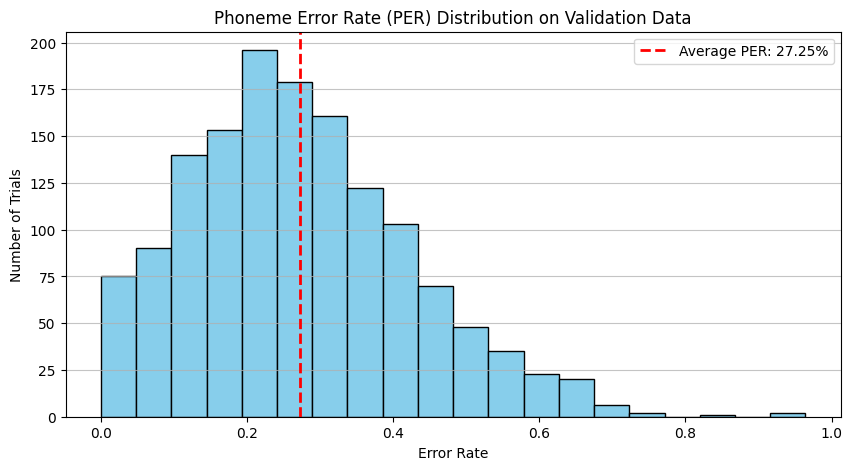

In [129]:
# Feed the index into the dataset
train_dataset = SpeechDataset(train_index, max_time_steps=1500)
val_dataset   = SpeechDataset(val_index, max_time_steps=1500)

# Create the samplers
train_sampler = BucketBatchSampler(train_dataset, batch_size=18)
val_sampler   = BucketBatchSampler(val_dataset, batch_size=18)

# Dataloaders
train_loader  = DataLoader(train_dataset, batch_sampler=train_sampler, prefetch_factor=2,
                           collate_fn=collate_fn, num_workers=2, pin_memory=True)
val_loader  = DataLoader(val_dataset, batch_sampler=val_sampler, prefetch_factor=2,
                         collate_fn=collate_fn, num_workers=2,pin_memory=True)

# ===============================================================
# 1. CTC Greedy Decoding
# ===============================================================
def ctc_greedy_decode(log_probs, blank_id=0):
    """
    Converts model log_probs (T, B, C) into a list of predicted sequences.
    Collapses repeated tokens and removes the blank token.
    """
    # Get the most likely class at each time step
    # Shape changes from (T, B, C) -> (T, B) -> transpose to (B, T)
    pred_ids = torch.argmax(log_probs, dim=-1).transpose(0, 1)

    decoded_preds = []
    for seq in pred_ids:
        decoded = []
        prev_token = -1
        for token in seq.tolist():
            if token != prev_token and token != blank_id:
                decoded.append(token)
            prev_token = token
        decoded_preds.append(decoded)

    return decoded_preds

# ===============================================================
# 2. Levenshtein Distance (Error Calculation)
# ===============================================================
def calculate_per(reference, hypothesis):
    """
    Calculates Phoneme Error Rate using Levenshtein distance.
    """
    m, n = len(reference), len(hypothesis)

    # Create distance matrix
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m + 1): dp[i][0] = i
    for j in range(n + 1): dp[0][j] = j

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            cost = 0 if reference[i - 1] == hypothesis[j - 1] else 1
            dp[i][j] = min(
                dp[i - 1][j] + 1,      # Deletion
                dp[i][j - 1] + 1,      # Insertion
                dp[i - 1][j - 1] + cost # Substitution
            )

    # PER = edit distance / length of reference
    edit_distance = dp[m][n]
    return edit_distance / m if m > 0 else 0.0

# ===============================================================
# 3. Evaluation Loop & Visualization
# ===============================================================
def evaluate_and_visualize(model, data_loader, device):
    model.eval()
    all_pers = []

    print("Evaluating unseen dataset...\n")
    print(f"{'True Sequence':<50} | {'Predicted Sequence':<50} | PER")
    print("-" * 115)

    with torch.no_grad():
        for neural_batch, phoneme_batch, seq_len_batch, _ in data_loader:
            neural_batch = neural_batch.to(device)

            # Forward pass
            log_probs, _ = model(neural_batch)

            # Decode predictions
            predictions = ctc_greedy_decode(log_probs, blank_id=0)

            # Process ground truth
            for i in range(len(neural_batch)):
                # Slice true phonemes up to their actual length (remove padding)
                true_len = seq_len_batch[i].item()
                true_seq = phoneme_batch[i][:true_len].tolist()
                pred_seq = predictions[i]

                # Calculate Error
                per = calculate_per(true_seq, pred_seq)
                all_pers.append(per)

                # Print the first 5 examples as a sanity check
                if len(all_pers) <= 5:
                    true_str = str(true_seq)
                    pred_str = str(pred_seq)

                    # Truncate strings for clean printing
                    if len(true_str) > 48: true_str = true_str[:45] + "..."
                    if len(pred_str) > 48: pred_str = pred_str[:45] + "..."

                    print(f"{true_str:<50} | {pred_str:<50} | {per:.2%}")

    # --- Visualization ---
    avg_per = np.mean(all_pers)

    plt.figure(figsize=(10, 5))
    plt.hist(all_pers, bins=20, color='skyblue', edgecolor='black')
    plt.axvline(avg_per, color='red', linestyle='dashed', linewidth=2, label=f'Average PER: {avg_per:.2%}')
    plt.title('Phoneme Error Rate (PER) Distribution on Validation Data')
    plt.xlabel('Error Rate')
    plt.ylabel('Number of Trials')
    plt.legend()
    plt.grid(axis='y', alpha=0.75)
    plt.show()

phase2_config = {
    'emb_size': 256,
    'num_electrodes': 512,
    'temporal_kernel': (1, 10),
    'pool_kernel': (1, 15),
    'pool_stride': (1, 8),
    'depth': 6,
    'num_heads': 8,
    'drop_p': 0.2,
    'num_phonemes': 40,
    'ffn_hidden': 256,
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = NeuralSpeechModel(phase2_config).to(device)

# Load latest weights into the model
weights_path = '/content/drive/MyDrive/SpeechModels/phase6_model_epoch_39_loss_0.9722.pth'
print(f"Loading weights from: {weights_path}")
model.load_state_dict(torch.load(weights_path, map_location=device))

evaluate_and_visualize(model, val_loader, device)

Loading Language Model and Tokenizer...


Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

Running Pipeline: Acoustic Model -> Language Model...

PER                | Predicted Text                      | True Text                           | WER
---------------------------------------------------------------------------------------------------------
41.67%             | The doors were okay front and bac   | The hogs were fed chopped corn an   | 62.50%
54.29%             | I would contemplate capital punis   | I would contemplate going on a cr   | 62.50%
29.17%             | So about a majority of the places   | So imagine all of his lines being   | 90.91%
32.00%             | The guy has had so many problems    | The girls at school are all weari   | 90.91%
36.67%             | And everything around the house i   | And everyone involved in the case   | 84.62%
35.82%             | He can occasionally call the next   | He can consistently score the dam   | 78.57%
41.30%             | It's too much to just sit this on   | Its too valuable to just let peop   | 60.00%
67.74%    

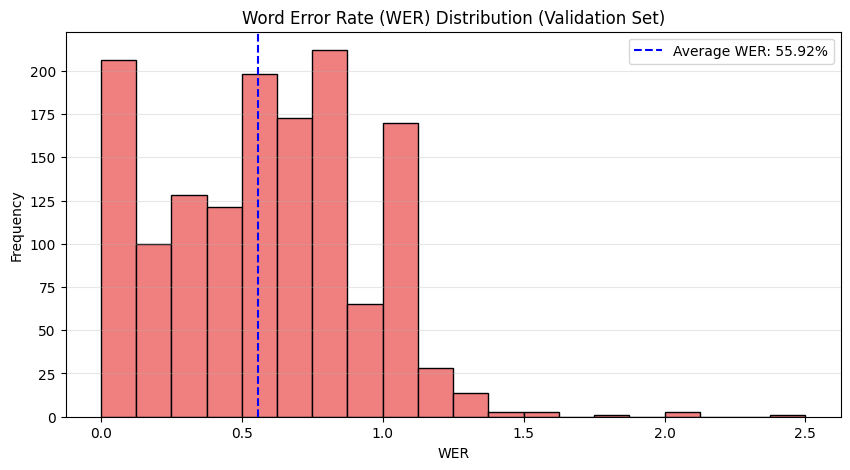

In [143]:
#Free memory
gc.collect()
torch.cuda.empty_cache()

# ===============================================================
# 1. Setup Language Model (LM)
# ===============================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Path where your Language Model was saved in the previous notebook
lm_path = "/content/drive/MyDrive/Language Module"
# Use the base BART model ID for the tokenizer, as used during training
model_id = "facebook/bart-base"

print("Loading Language Model and Tokenizer...")

config = AutoConfig.from_pretrained(lm_path)
lm_model = AutoModelForSeq2SeqLM.from_pretrained(lm_path, config=config).to(device)
lm_tokenizer = AutoTokenizer.from_pretrained(lm_path)

lm_model.eval()

# ===============================================================
# 2. Updated Dataset to include Text Labels
# ===============================================================
class SpeechDatasetWithText(TorchDataset):
    def __init__(self, data_dict, max_time_steps):
        self.data = data_dict
        self.length = len(data_dict['neural_features'])
        self.max_time_steps = max_time_steps

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        n_time_steps = int(self.data['n_time_steps'][idx])
        seq_len = int(self.data['seq_len'][idx])
        effective_n_steps = min(n_time_steps, self.max_time_steps)

        neural = self.data['neural_features'][idx][:effective_n_steps]
        phonemes = self.data['seq_class_ids'][idx][:seq_len]

        # Extract and decode the text label
        text_label = self.data['sentence_label'][idx]
        if isinstance(text_label, bytes):
            text_label = text_label.decode('utf-8')

        neural_tensor = torch.from_numpy(neural).float().transpose(0, 1).unsqueeze(0)
        phoneme_tensor = torch.from_numpy(phonemes.astype(np.int64))

        return neural_tensor, phoneme_tensor, seq_len, effective_n_steps, text_label

def collate_fn_with_text(batch):
    neurals, phonemes_list, seq_lens, time_steps, texts = zip(*batch)
    neurals_reshaped = [n.squeeze(0).transpose(0, 1) for n in neurals]
    neural_batch = pad_sequence(neurals_reshaped, batch_first=True).transpose(1, 2).unsqueeze(1)
    phoneme_batch = pad_sequence(phonemes_list, batch_first=True, padding_value=0)
    return neural_batch, phoneme_batch, torch.tensor(seq_lens), torch.tensor(time_steps), texts

# Re-initialize Validation Loader with text labels
val_dataset_text = SpeechDatasetWithText(val_index, max_time_steps=1500)
val_sampler_text = BucketBatchSampler(val_dataset_text, batch_size=28)
val_loader_text = DataLoader(val_dataset_text, batch_sampler=val_sampler_text,
                             collate_fn=collate_fn_with_text, num_workers=2, pin_memory=True)

# ===============================================================
# 3. WER Calculation (Levenshtein on Words)
# ===============================================================
def calculate_wer(reference, hypothesis):
    ref_clean = re.sub(r'[^\w\s]', '', reference.lower())
    hyp_clean = re.sub(r'[^\w\s]', '', hypothesis.lower())

    ref_words = ref_clean.split()
    hyp_words = hyp_clean.split()

    m, n = len(ref_words), len(hyp_words)
    if m == 0: return 1.0 if n > 0 else 0.0

    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m + 1): dp[i][0] = i
    for j in range(n + 1): dp[0][j] = j

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            cost = 0 if ref_words[i-1] == hyp_words[j-1] else 1
            dp[i][j] = min(dp[i-1][j] + 1, dp[i][j-1] + 1, dp[i-1][j-1] + cost)

    return dp[m][n] / m

# ===============================================================
# 4. Final Inference and Visualization
# ===============================================================
def evaluate_pipeline(acoustic_model, lm_model, lm_tokenizer, data_loader, device):
    acoustic_model.eval()
    lm_model.eval()
    all_wers = []
    samples = []

    print("Running Pipeline: Acoustic Model -> Language Model...")
    with torch.no_grad():
        # 1. Unpack phoneme_batch and seq_lens (removed the underscores)
        for neural_batch, phoneme_batch, seq_lens, input_time_steps, text_labels in data_loader:
            neural_batch = neural_batch.to(device)
            k_w, s_w = acoustic_model.config['pool_kernel'][1], acoustic_model.config['pool_stride'][1]
            input_lengths = ((input_time_steps - k_w) // s_w + 1).long().to(device)

            # Phase 1: Acoustic Prediction
            log_probs, _ = acoustic_model(neural_batch, input_lengths)
            predictions = ctc_greedy_decode(log_probs, blank_id=0)

            # Phase 2: Language Model Refinement
            for i, phoneme_ids in enumerate(predictions):

                # 2. Extract true sequence and calculate PER
                true_len = seq_lens[i].item()
                true_seq = phoneme_batch[i][:true_len].tolist()
                per = calculate_per(true_seq, phoneme_ids)

                # --- CORRECTED INPUT FOR LM ---
                # Convert phoneme_ids (list of ints) to phoneme string format
                phoneme_string = " ".join([f"<p{x}>" for x in phoneme_ids])
                # Tokenize the phoneme string to get input_ids for BART
                input_encoding = lm_tokenizer(
                    phoneme_string,
                    return_tensors="pt",
                    max_length=256, # Match max_length used in training
                    truncation=True
                ).to(device)

                # Generate text using the correctly tokenized input_ids
                outputs = lm_model.generate(
                    input_ids=input_encoding.input_ids,
                    attention_mask=input_encoding.attention_mask,
                    max_length=256,
                    num_beams=4,
                    length_penalty=0.6,
                    repetition_penalty=1.2
  )
                predicted_text = lm_tokenizer.decode(outputs[0], skip_special_tokens=True)
                true_text = text_labels[i]

                wer = calculate_wer(true_text, predicted_text)
                all_wers.append(wer)

                # 3. Save the calculated PER instead of the raw phoneme array
                if len(samples) < 10:
                    samples.append({
                        'per': per,
                        'pred': predicted_text,
                        'true': true_text,
                        'wer': wer
                    })

    # Display 10 Samples
    print(f"\n{'PER':<18} | {'Predicted Text':<35} | {'True Text':<35} | {'WER'}")
    print("-" * 105)
    for s in samples:
        # Format the PER as a percentage
        per_str = f"{s['per']:.2%}"
        print(f"{per_str:<18} | {s['pred'][:33]:<35} | {s['true'][:33]:<35} | {s['wer']:.2%}")

    # Plot WER Distribution
    avg_wer = np.mean(all_wers)
    plt.figure(figsize=(10, 5))
    plt.hist(all_wers, bins=20, color='lightcoral', edgecolor='black')
    plt.axvline(avg_wer, color='blue', linestyle='dashed', label=f'Average WER: {avg_wer:.2%}')
    plt.title('Word Error Rate (WER) Distribution (Validation Set)')
    plt.xlabel('WER')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# Execute
evaluate_pipeline(model, lm_model, lm_tokenizer, val_loader_text, device)